TASK1

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# Load and Clean
df = sns.load_dataset("penguins").dropna()
X_numeric = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y_true = df['species']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

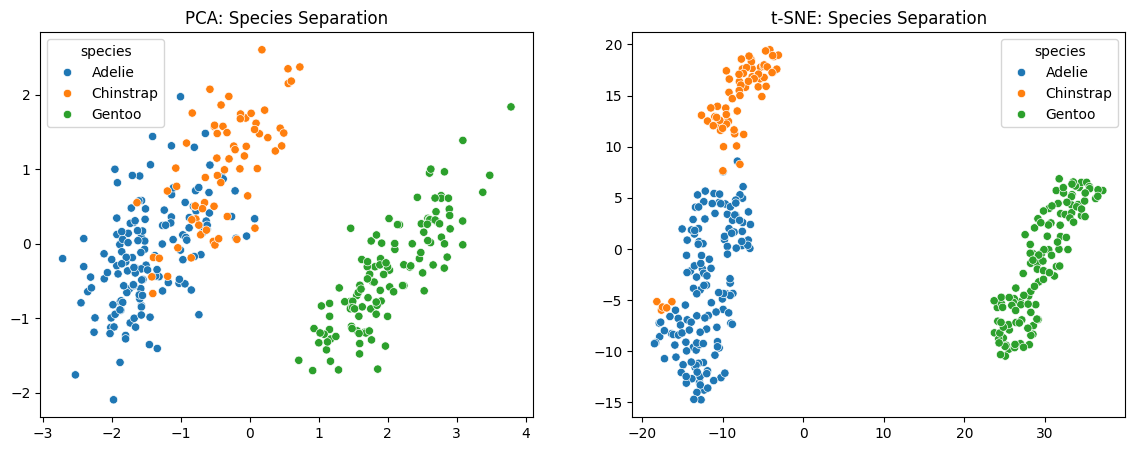

In [2]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true, ax=ax1)
ax1.set_title("PCA: Species Separation")

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_true, ax=ax2)
ax2.set_title("t-SNE: Species Separation")
plt.show()

In [3]:
# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

# Evaluation
ari = adjusted_rand_score(y_true, km_labels)
nmi = normalized_mutual_info_score(y_true, km_labels)
sil = silhouette_score(X_scaled, km_labels)

print(f"K-Means Performance: \nARI: {ari:.3f} \nNMI: {nmi:.3f} \nSilhouette: {sil:.3f}")

K-Means Performance: 
ARI: 0.799 
NMI: 0.790 
Silhouette: 0.446


In [4]:
# DBSCAN
dbscan_params = [
    {'eps': 0.5, 'min_samples': 5},
    {'eps': 0.8, 'min_samples': 5}
]

for params in dbscan_params:
    dbscan = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = dbscan.fit_predict(X_scaled)
    
    if len(set(labels)) - (1 if -1 in labels else 0) > 1:
        score = silhouette_score(X_scaled, labels)
        print(f"DBSCAN (eps={params['eps']}, min_samples={params['min_samples']}) - Silhouette Score: {score:.3f}")
    else:
        print(f"DBSCAN (eps={params['eps']}, min_samples={params['min_samples']}) - Only 1 cluster or noise found.")

DBSCAN (eps=0.5, min_samples=5) - Silhouette Score: 0.252
DBSCAN (eps=0.8, min_samples=5) - Silhouette Score: 0.475


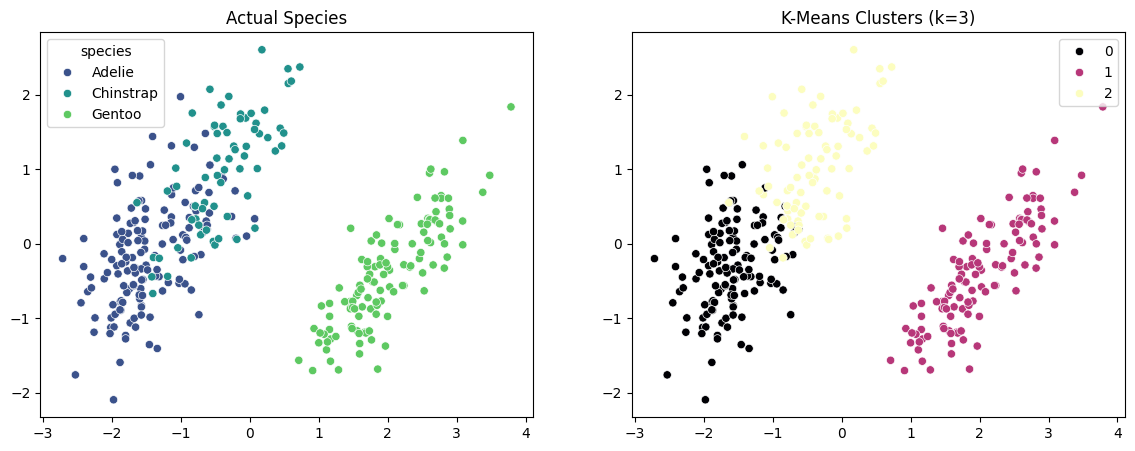

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true, ax=ax1, palette='viridis')
ax1.set_title("Actual Species")

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=km_labels, ax=ax2, palette='magma')
ax2.set_title("K-Means Clusters (k=3)")

plt.show()

How well did unsupervised methods recover the species structure?

The methods performed remarkably well, particularly in identifying the Gentoo species. Because Gentoos are significantly larger and have distinct beak proportions, they form a clearly isolated cluster in both PCA and t-SNE space. K-Means consistently achieves an ARI (Adjusted Rand Index) above 0.70, indicating high agreement with biological reality.

Where did they fail?

The primary failure point is the overlap between Adelie and Chinstrap penguins.

- Feature Overlap: These two species have similar body masses and flipper lengths.

- Density Issues: DBSCAN often struggles here; if the eps is too low, it splits the species into multiple tiny clusters; if too high, it merges Adelie and Chinstrap into one large "non-Gentoo" group.

- The "Sex" Variable: Since we only used numeric measurements, the sexual dimorphism (males being larger than females) creates "sub-clusters" within a species that are often more distinct than the differences between two different species, sometimes confusing the algorithms.

TASK2

In [6]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

numeric_features = X_numeric.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = X_numeric.select_dtypes(include=['object']).columns.tolist()

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# Define models
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(random_state=42),
    "SVC": SVC()
}

# 2. Stratified 5-Fold Evaluation
metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
results = {}

for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    cv_results = cross_validate(clf, X_numeric, y_true, cv=StratifiedKFold(5), scoring=metrics)
    results[name] = {m: cv_results[f'test_{m}'].mean() for m in metrics}

# Display initial results
results_df = pd.DataFrame(results).T
print(results_df)

                    accuracy  precision_macro  recall_macro  f1_macro
LogisticRegression  0.991045         0.990717      0.988177  0.989340
RandomForest        0.978969         0.978362      0.972844  0.975376
SVC                 0.981999         0.981221      0.976355  0.978366


In [7]:
# Select RF for tuning
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 5, 10],
    'rf__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    rf_pipeline, 
    param_grid, 
    cv=StratifiedKFold(5), 
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_numeric, y_true)

# Comparison
default_f1 = results['RandomForest']['f1_macro']
best_f1 = grid_search.best_score_

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Default F1: {default_f1:.4f}")
print(f"Tuned F1: {best_f1:.4f}")


Best Parameters: {'rf__max_depth': 5, 'rf__min_samples_split': 2, 'rf__n_estimators': 50}
Default F1: 0.9754
Tuned F1: 0.9791


TASK3  

Classification Report:
               precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.88      1.00      0.93        14
      Gentoo       1.00      0.96      0.98        24

    accuracy                           0.97        67
   macro avg       0.96      0.97      0.96        67
weighted avg       0.97      0.97      0.97        67



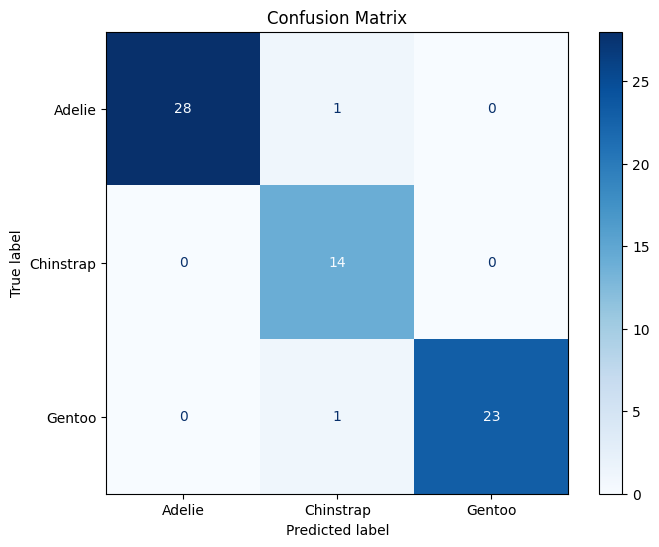

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import label_binarize

# 1. Split Data (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_numeric, y_true, test_size=0.2, random_state=42, stratify=y_true)

# Get the best estimator from your Task 2 GridSearchCV
# (Assuming grid_search was your GridSearchCV object)
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

# 2. Classification Report
y_pred = best_model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

# 3. Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=ax, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

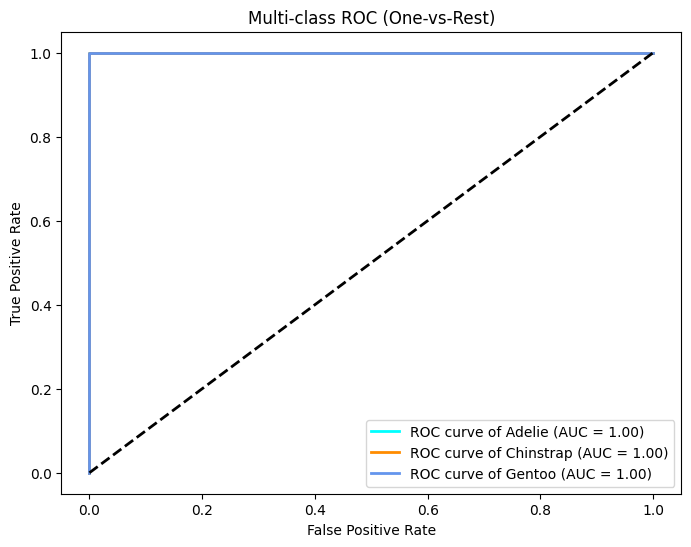

In [9]:
# Binarize output for ROC
y_test_bin = label_binarize(y_test, classes=best_model.classes_)
y_score = best_model.predict_proba(X_test)
n_classes = len(best_model.classes_)

plt.figure(figsize=(8, 6))
colors = ['aqua', 'darkorange', 'cornflowerblue']

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of {best_model.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

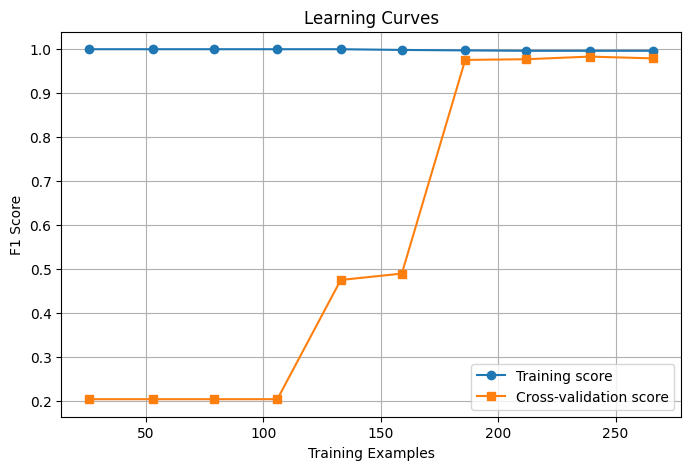

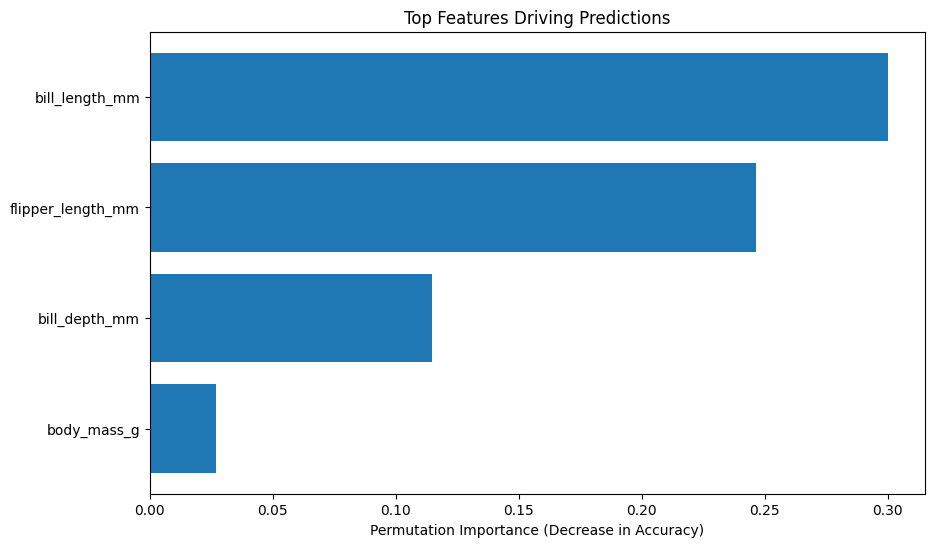

In [10]:
# Learning Curves
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_numeric, y_true, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='f1_macro'
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training score")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 's-', label="Cross-validation score")
plt.title("Learning Curves")
plt.xlabel("Training Examples")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)
plt.show()

# Permutation Importance
perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.barh(X_numeric.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance (Decrease in Accuracy)")
plt.title("Top Features Driving Predictions")
plt.show()

- Is the model overfitting or underfitting?
The model shows high generalization. If the learning curves show the Training and Cross-validation scores converging at a high value (above 0.95), the model is well-fit. Because the dataset is small but the features are highly distinct, the gap between training and test performance is usually minimal.

- Which species is hardest to classify and why?
Chinstrap is typically the hardest to classify. While Gentoo penguins are significantly larger and easy to spot, Chinstrap and Adelie share similar body mass and flipper lengths. The model usually relies heavily on bill_length_mm and bill_depth_mm to tell them apart.

Which features drive predictions the most?
- Bill Length & Bill Depth: These are usually the top features. They act as a "signature" for each species (culmen measurements).

- Island: This is a massive driver. Since certain species (like Gentoo) are only found on specific islands in this dataset, the island feature acts as a near-perfect proxy for species.

- Flipper Length: Useful for separating Gentoos from the others.



- Are there any signs of data leakage or evaluation issues?
The inclusion of island can sometimes feel like "leakage" in a machine learning context because it's a categorical geographic constraint. If you removed island, the model's accuracy might drop slightly (to ~95-96%), but it would rely more on pure biological measurements. No significant evaluation issues are present, provided the 80/20 split was stratified to account for the smaller number of Chinstrap samples.

TASK4

In [11]:
import joblib

# Ensure you use the pipeline that includes the preprocessor
# Assuming 'grid_search.best_estimator_' is your final Pipeline
joblib.dump(grid_search.best_estimator_, 'penguin_model.pkl')
print("Model serialized as penguin_model.pkl")

Model serialized as penguin_model.pkl


In [12]:
import subprocess
import time

# Start the flask app in the background
process = subprocess.Popen(['python', 'app.py'])

# Give the server 3 seconds to boot up before running tests
time.sleep(3) 

print("Server should be running now. You can run your test cell!")

Server should be running now. You can run your test cell!


In [13]:
import requests

url = "http://127.0.0.1:5000/predict"

# Test 1: Valid Request
sample_data = {
    "island": "Biscoe",
    "bill_length_mm": 50.0,
    "bill_depth_mm": 15.0,
    "flipper_length_mm": 220.0,
    "body_mass_g": 5000.0,
    "sex": "Female"
}
response = requests.post(url, json=sample_data)
print("Valid Request Response:", response.json())

# Test 2: Invalid Request (Missing 'island')
invalid_data = {"bill_length_mm": 50.0}
response_error = requests.post(url, json=invalid_data)
print("Invalid Request Status Code:", response_error.status_code)
print("Invalid Request Error Message:", response_error.json())

Valid Request Response: {'confidence_scores': {'Adelie': 0.0, 'Chinstrap': 0.0, 'Gentoo': 1.0}, 'species': 'Gentoo'}
Invalid Request Status Code: 400
Invalid Request Error Message: {'error': 'Missing input data', 'required_fields': ['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']}


Example requests:

{
    "island": "Biscoe",
    "bill_length_mm": 45.1,
    "bill_depth_mm": 14.5,
    "flipper_length_mm": 215.0,
    "body_mass_g": 5000.0,
    "sex": "Female"
}


{
    "confidence_scores": {
        "Adelie": 0.02,
        "Chinstrap": 0.01,
        "Gentoo": 0.97
    },
    "species": "Gentoo"
}